In [7]:
!pip install torchtext==0.15.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 33.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 61.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 56.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 58.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 34.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 40.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 MB 66.4 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 MB 59.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2/

In [1]:
%%capture
import warnings
from tqdm import tqdm

warnings.simplefilter('ignore')
import time
from collections import OrderedDict

import re

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import string
import time
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from nltk.tokenize import word_tokenize

from sklearn.manifold import TSNE

# You can also use this section to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

In [2]:
song= """We are no strangers to love
You know the rules and so do I
A full commitments what Im thinking of
You wouldnt get this from any other guy
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
And if you ask me how Im feeling
Dont tell me youre too blind to see
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Weve known each other for so long
Your hearts been aching but youre too shy to say it
Inside we both know whats been going on
We know the game and were gonna play it
I just wanna tell you how Im feeling
Gotta make you understand
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you
Never gonna give you up
Never gonna let you down
Never gonna run around and desert you
Never gonna make you cry
Never gonna say goodbye
Never gonna tell a lie and hurt you"""

In [3]:
tokenizer = get_tokenizer("basic_english")
tokens = tokenizer(song)


In [4]:
def preprocess_string(s):
    """
    Preprocesses a given string by performing the following steps:
    
    1. Removes all non-word characters (excluding letters and numbers).
    2. Removes all whitespace characters.
    3. Removes all numeric digits.

    Parameters:
    s (str): The input string to be cleaned.

    Returns:
    str: The processed string with only alphabetic characters, no spaces, and no digits.
    """

    # Remove all non-word characters (everything except letters and numbers)
    # \w matches any word character (letters, numbers, and underscores)
    # \s matches any whitespace characters
    # ^ inside [] negates the selection, so [^\w\s] matches anything that's NOT a word character or whitespace.
    s = re.sub(r"[^\w\s]", '', s)

    # Remove all whitespace characters (spaces, tabs, newlines)
    # \s+ matches one or more whitespace characters.
    s = re.sub(r"\s+", '', s)

    # Remove all digits (0-9)
    # \d matches any digit character.
    s = re.sub(r"\d", '', s)

    return s

In [5]:
def preprocess(words):
    """
    Preprocesses a given text by tokenizing it, cleaning individual words, and 
    converting them to lowercase while removing empty or punctuation tokens.

    Steps:
    1. Tokenization: Splits the input text into individual word tokens.
    2. Cleaning: Applies `preprocess_string()` to remove non-word characters, 
       spaces, and digits from each token.
    3. Normalization: Converts all tokens to lowercase.
    4. Filtering: Removes empty strings and punctuation tokens.

    Parameters:
    words (str): The input text to be tokenized and preprocessed.

    Returns:
    list: A list of cleaned, lowercase tokens.
    """

    # Tokenize the input text into words
    tokens = word_tokenize(words)

    # Apply preprocessing to each token (removes unwanted characters)
    tokens = [preprocess_string(w) for w in tokens]

    # Convert tokens to lowercase and remove empty strings or punctuation
    return [w.lower() for w in tokens if len(w) != 0 and w not in string.punctuation]

# Example usage:
tokens = preprocess(song)  # Preprocess the text in 'song'

In [6]:
def tokenizetext(song):
    """
    Tokenizes the input text (song) and builds a vocabulary from the tokens.

    Steps:
    1. Tokenization: The function splits the input text into words and applies 
       a tokenizer function to each word.
    2. Vocabulary Building: Constructs a vocabulary from the tokenized words,
       including a special "<unk>" token to handle out-of-vocabulary words.
    3. Default Indexing: Sets the default index for unknown words, ensuring 
       that any unseen tokens are mapped to "<unk>".

    Parameters:
    song (str): The input text (song lyrics) to be tokenized and processed.

    Returns:
    vocab (Vocab): A vocabulary object mapping tokens to their corresponding indices.
    """

    # Tokenize the text
    # Split the input text into words and apply the tokenizer function to each word.
    # The 'map' function ensures that each word is tokenized properly.
    tokenized_song = map(tokenizer, song.split())

    # Build vocabulary from tokenized text
    # The function `build_vocab_from_iterator` constructs a vocabulary by iterating 
    # over the tokenized words. The special token "<unk>" is added to handle words 
    # that are not present in the vocabulary.
    vocab = build_vocab_from_iterator(tokenized_song, specials=["<unk>"])

    # Set the default index for unknown words
    # The default index is set to the index of "<unk>" so that any word not found 
    # in the vocabulary is mapped to this token, preventing errors during lookup.
    vocab.set_default_index(vocab["<unk>"])

    return vocab


In [7]:
vocab=tokenizetext(song)
vocab(tokens[0:10])

[21, 58, 70, 74, 25, 69, 2, 20, 31, 72]

In [8]:
tokens[0:10]

['we', 'are', 'no', 'strangers', 'to', 'love', 'you', 'know', 'the', 'rules']

In [9]:
text_pipeline = lambda x: vocab(tokenizer(x))
text_pipeline(song)[0:10]

[21, 58, 70, 74, 25, 69, 2, 20, 31, 72]

In [10]:
index_to_token = vocab.get_itos()
index_to_token[58]

'are'

In [11]:
def genembedding(vocab):
    """
    Generates an embedding layer for the given vocabulary.

    The embedding layer transforms words into dense vector representations, 
    allowing the model to learn semantic relationships between words.

    Parameters:
    vocab (Vocab): The vocabulary object containing unique words and their indices.

    Returns:
    nn.Embedding: A PyTorch embedding layer with a specified embedding dimension.
    """

    # Define the embedding dimension (size of word vectors)
    embedding_dim = 20  # Each word will be represented as a 20-dimensional vector

    # Get the vocabulary size (number of unique words in the vocabulary)
    vocab_size = len(vocab)

    # Create an embedding layer
    # The nn.Embedding module maps word indices to dense vector representations.
    # It takes vocab_size as the number of words and embedding_dim as the vector size.
    embeddings = nn.Embedding(vocab_size, embedding_dim)

    return embeddings

In [12]:
embeddings=genembedding(vocab)
for n in range(2): 
    embedding=embeddings(torch.tensor(n))
    print("word",index_to_token[n])
    print("index",n)
    print( "embedding", embedding)
    print("embedding shape", embedding.shape)

word <unk>
index 0
embedding tensor([ 1.0329, -1.8042,  0.7188,  0.1387,  0.6012,  0.0294,  0.2941, -1.3322,
         0.2055,  0.6515, -0.9909, -1.2489, -0.4347, -0.4631, -0.1668,  0.6419,
         0.6205,  0.4408,  0.4597, -1.2250], grad_fn=<EmbeddingBackward0>)
embedding shape torch.Size([20])
word gonna
index 1
embedding tensor([ 0.6498, -0.8793, -0.3474, -0.0253, -1.0811,  2.3770,  1.6328, -1.4692,
        -0.6883, -0.9304, -0.0091, -0.6887, -1.0257,  1.1391, -1.5306,  0.2926,
         0.9513,  0.9609, -0.5501, -0.0200], grad_fn=<EmbeddingBackward0>)
embedding shape torch.Size([20])


In [13]:
# Define the context size for generating n-grams
CONTEXT_SIZE = 2  # The number of previous words used to predict the next word

def genngrams(tokens):
    """
    Generates n-grams from a list of tokens, where each n-gram consists of a 
    context (previous words) and a target (next word).

    The function constructs a list of tuples where:
    - The first element is a list of `CONTEXT_SIZE` previous words.
    - The second element is the target word that follows the context.

    Parameters:
    tokens (list): A list of preprocessed word tokens.

    Returns:
    list: A list of tuples representing n-grams.
          Each tuple contains (context_words, target_word).
    """

    # Generate n-grams
    # Iterate through the tokens starting from index CONTEXT_SIZE to the end
    # For each token at position 'i', extract the previous CONTEXT_SIZE words as context
    ngrams = [
        (
            [tokens[i - j - 1] for j in range(CONTEXT_SIZE)],  # Context words (previous words)
            tokens[i]  # Target word (the word to predict)
        )
        for i in range(CONTEXT_SIZE, len(tokens))
    ]

    return ngrams


In [14]:
ngrams=genngrams(tokens)
context, target=ngrams[0]
print("context",context,"target",target)
print("context index",vocab(context),"target index",vocab([target]))

context ['are', 'we'] target no
context index [58, 21] target index [70]


In [15]:
embedding_dim=20
linear = nn.Linear(embedding_dim*CONTEXT_SIZE,128)

In [16]:
embeddings=genembedding(vocab)
my_embeddings=embeddings(torch.tensor(vocab(context)))
my_embeddings.shape

torch.Size([2, 20])

In [17]:
my_embeddings=my_embeddings.reshape(1,-1)
my_embeddings.shape

torch.Size([1, 40])

In [18]:
linear(my_embeddings)

tensor([[-0.1500,  0.2020,  0.6467, -0.4991, -0.1086, -0.1095, -0.1095, -0.5562,
         -0.6452,  0.4409,  0.2182, -0.8190,  0.7453, -0.9444,  1.0417,  0.9627,
         -1.2084,  0.4262,  0.2039,  0.7417,  0.0872, -1.7233,  0.0599,  0.2777,
          0.0045, -0.1377,  0.0023, -0.0798, -0.8062, -0.6448,  0.8106, -0.6762,
         -0.3101,  1.0707,  0.4138, -0.1855, -0.6981, -0.1266,  0.9130,  0.3614,
         -0.1598,  0.8682, -0.0666,  0.4614,  0.7078,  0.2654, -0.4001,  0.2792,
          0.4174,  0.8300, -0.3068,  0.8233,  0.0090,  0.1302, -0.0970,  0.4221,
         -0.6791,  0.0628,  0.7202, -0.1393,  0.3164,  0.2249, -0.7958, -0.1304,
         -0.4481, -0.1900, -0.9859,  0.6418, -0.3402, -0.0584,  1.0159,  0.3329,
          0.4351,  0.0175,  0.3823, -0.3396, -0.1763,  0.0488, -0.1264,  0.5934,
         -1.2198,  0.5084,  0.1794,  1.3385, -0.1096,  0.1175, -0.3875, -1.0130,
         -0.7173,  0.3642, -0.6812,  0.7984,  0.4532, -0.3031,  0.0882,  0.7511,
         -0.4914,  0.3090,  

In [19]:
from torch.utils.data import DataLoader  # Importing DataLoader for batch processing
import torch  # Importing PyTorch

# Set the device to GPU if available; otherwise, use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define hyperparameters
CONTEXT_SIZE = 3   # Number of previous words used as context for prediction
BATCH_SIZE = 10    # Number of samples per training batch
EMBEDDING_DIM = 10 # Dimension of word embeddings

def collate_batch(batch):
    """
    Processes a batch of text data into input (context) and output (target) tensors
    for training a language model.

    The function extracts:
    - `context`: A list of word indices representing the context words for each target word.
    - `target`: A list of word indices representing the target word to predict.

    Parameters:
    batch (list): A list of tokenized words (strings).

    Returns:
    tuple: Two PyTorch tensors: (context_tensor, target_tensor)
           - context_tensor: Tensor of shape (batch_size - CONTEXT_SIZE, CONTEXT_SIZE),
             containing the word indices of context words.
           - target_tensor: Tensor of shape (batch_size - CONTEXT_SIZE,),
             containing the word indices of target words.
    """

    batch_size = len(batch)  # Get the size of the batch
    context, target = [], [] # Initialize lists for context and target words

    # Loop through the batch, ensuring enough previous words exist for context
    for i in range(CONTEXT_SIZE, batch_size):
        # Convert the target word to its index using the vocabulary
        target.append(vocab([batch[i]]))

        # Convert the previous CONTEXT_SIZE words to indices using the vocabulary
        context.append(vocab([batch[i - j - 1] for j in range(CONTEXT_SIZE)]))

    # Convert lists to PyTorch tensors and move them to the appropriate device (CPU/GPU)
    return torch.tensor(context).to(device), torch.tensor(target).to(device).reshape(-1)


In [20]:
Padding=BATCH_SIZE-len(tokens)%BATCH_SIZE
tokens_pad=tokens+tokens[0:Padding]


In [21]:
dataloader = DataLoader(
     tokens_pad, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)

In [22]:
class NGramLanguageModeler(nn.Module):
    """
    A neural network-based n-gram language model that predicts the next word 
    given a sequence of context words.

    This model consists of:
    - An embedding layer that converts word indices into dense vector representations.
    - A fully connected hidden layer with ReLU activation.
    - An output layer that predicts the probability distribution over the vocabulary.

    Parameters:
    vocab_size (int): The number of unique words in the vocabulary.
    embedding_dim (int): The size of the word embeddings (vector representation of words).
    context_size (int): The number of previous words used as context to predict the next word.
    """

    def __init__(self, vocab_size, embedding_dim, context_size):
        super(NGramLanguageModeler, self).__init__()

        # Store context size and embedding dimension
        self.context_size = context_size
        self.embedding_dim = embedding_dim

        # Embedding layer: Maps word indices to dense vectors
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)

        # Fully connected hidden layer: Maps the concatenated embeddings to a 128-dimensional space
        self.linear1 = nn.Linear(context_size * embedding_dim, 128)

        # Output layer: Maps the hidden layer output to vocabulary size (probability distribution over words)
        self.linear2 = nn.Linear(128, vocab_size)

    def forward(self, inputs):
        """
        Forward pass of the model.

        Parameters:
        inputs (Tensor): A tensor of shape (batch_size, context_size) containing word indices.

        Returns:
        Tensor: A tensor of shape (batch_size, vocab_size) representing predicted probabilities for the next word.
        """

        # Convert input word indices into dense vectors using the embedding layer
        embeds = self.embeddings(inputs)  # Shape: (batch_size, context_size, embedding_dim)

        # Reshape the embeddings into a single vector per input sample
        embeds = torch.reshape(embeds, (-1, self.context_size * self.embedding_dim))  
        # New shape: (batch_size, context_size * embedding_dim)

        # Apply first fully connected layer with ReLU activation
        out = F.relu(self.linear1(embeds))  # Shape: (batch_size, 128)

        # Apply second fully connected layer to generate vocabulary-size logits
        out = self.linear2(out)  # Shape: (batch_size, vocab_size)

        return out


In [23]:
model = NGramLanguageModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE).to(device)

In [24]:
context, target=next(iter(dataloader))
print(context, target)
out=model(context)

tensor([[70, 58, 21],
        [74, 70, 58],
        [25, 74, 70],
        [69, 25, 74],
        [ 2, 69, 25],
        [20,  2, 69],
        [31, 20,  2]]) tensor([74, 25, 69,  2, 20, 31, 72])


In [25]:
out.shape

torch.Size([7, 79])

In [26]:
predicted_index =torch.argmax(out,1)
predicted_index

tensor([32, 17, 78, 34, 65, 19, 65])

In [27]:
[index_to_token[i.item()] for i in  predicted_index]

['too', 'lie', 'wouldnt', 'aching', 'full', 'up', 'full']

In [28]:
def write_song(model, my_song, number_of_words=100):
    """
    Generates text using a trained n-gram language model.

    Given an initial text (`my_song`), the function generates additional words by 
    predicting the next word iteratively based on the trained model.

    Parameters:
    model (nn.Module): The trained n-gram language model.
    my_song (str): The initial seed text to start generating words.
    number_of_words (int): The number of words to generate (default: 100).

    Returns:
    str: The generated song lyrics as a string.
    """

    # Get the mapping from index to word for decoding predictions
    index_to_token = vocab.get_itos()

    # Loop to generate the desired number of words
    for i in range(number_of_words):

        with torch.no_grad():  # Disable gradient computation for inference
            
            # Prepare the input context by extracting the last CONTEXT_SIZE words from tokens
            context = torch.tensor(
                vocab([tokens[i - j - 1] for j in range(CONTEXT_SIZE)])
            ).to(device)  # Move to CPU/GPU as required
            
            # Predict the next word by selecting the word with the highest probability
            word_idx = torch.argmax(model(context))  # Get index of the most likely next word
            
            # Append the predicted word to the generated text
            my_song += " " + index_to_token[word_idx.detach().item()]

    return my_song  # Return the generated lyrics


In [29]:
def pickrandomline(song):
    """
    Selects a random line from the given song text.

    This function splits the song into separate lines and randomly picks one of them.

    Parameters:
    song (str): The song lyrics as a multi-line string.

    Returns:
    str: A randomly selected line from the song.
    """
    
    # Split the song into individual lines
    lines = song.split("\n")  
    
    # Randomly select a line and remove leading/trailing whitespace
    selected_line = random.choice(lines).strip()
    
    return selected_line  # Return the randomly selected line

# Example usage:
selected_line = pickrandomline(song)  # Pick a random line from the song

# Generate a new song starting with the selected line
generated_song = write_song(model, selected_line)

# Print the generated lyrics
print(generated_song)


I just wanna tell you how Im feeling i lie been too lie wouldnt aching full up full going run wouldnt so known known known been wouldnt wouldnt aching see aching full both known aching down blind known known known full wouldnt wouldnt i full known been full wouldnt wouldnt i known wouldnt hearts i how wouldnt been wouldnt wouldnt i how full been full i i how i i the i known wouldnt i wouldnt i known run down i hearts i known wouldnt i wouldnt i of been the i known known known known aching i known known the around i been lie known around known


In [30]:
criterion = torch.nn.CrossEntropyLoss()

In [31]:
def train(dataloader, model,song,number_of_epochs=100, show=10):
    """
    Args:
        dataloader (DataLoader): DataLoader containing training data.
        model (nn.Module): Neural network model to be trained.
        number_of_epochs (int, optional): Number of epochs for training. Default is 100.
        show (int, optional): Interval for displaying progress. Default is 10.

    Returns:
        list: List containing loss values for each epoch.
    """

    MY_LOSS = []  # List to store loss values for each epoch

    # Iterate over the specified number of epochs
    for epoch in tqdm(range(number_of_epochs)):
        total_loss = 0  # Initialize total loss for the current epoch
        my_song = ""    # Initialize a string to store the generated song

        # Iterate over batches in the dataloader
        for context, target in dataloader:
            model.zero_grad()          # Zero the gradients to avoid accumulation
            predicted = model(context)  # Forward pass through the model to get predictions
            loss = criterion(predicted, target.reshape(-1))  # Calculate the loss
            total_loss += loss.item()   # Accumulate the loss

            loss.backward()    # Backpropagation to compute gradients
            optimizer.step()   # Update model parameters using the optimizer

        # Display progress and generate song at specified intervals
        if epoch % show == 0:
            selected_line=pickrandomline(song)
            my_song += write_song(model, selected_line)    # Generate song using the model

            print("Generated Song:")
            print("\n")
            print(my_song)

        MY_LOSS.append(total_loss/len(dataloader))  # Append the total loss for the epoch to MY_LOSS list

    return MY_LOSS  # Return the list of  mean loss values for each epoch

In [32]:
my_loss_list=[]

In [33]:
# Define the context size for the n-gram model
CONTEXT_SIZE = 2

# Create an instance of the NGramLanguageModeler class with specified parameters
model_2 = NGramLanguageModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE).to(device)

# Define the optimizer for training the model, using stochastic gradient descent (SGD)
optimizer = optim.SGD(model_2.parameters(), lr=0.01)

# Set up a learning rate scheduler using StepLR to adjust the learning rate during training
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1.0, gamma=0.1)

In [34]:
my_loss=train(dataloader,model_2,song)

  6%|▌         | 6/100 [00:00<00:03, 27.88it/s]

Generated Song:


Your hearts been aching but youre too shy to say it never never desert <unk> of you you never <unk> make <unk> <unk> do do <unk> cry <unk> <unk> make never make <unk> hurt never make your cry <unk> never <unk> <unk> you what <unk> <unk> hurt never never never <unk> <unk> you do <unk> <unk> <unk> <unk> understand make <unk> <unk> <unk> <unk> hurt make <unk> <unk> <unk> <unk> <unk> <unk> <unk> you inside <unk> <unk> <unk> you do <unk> <unk> <unk> <unk> never make what <unk> <unk> <unk> hurt never <unk> you never <unk> cry <unk> im <unk> <unk> hurt strangers <unk> <unk> you dont strangers <unk> you give


 16%|█▌        | 16/100 [00:00<00:02, 29.22it/s]

Generated Song:


Never gonna run around and desert you never never never never <unk> you <unk> never never never <unk> <unk> you you <unk> <unk> <unk> <unk> <unk> never never <unk> you never never never you <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> never never never never <unk> <unk> you you never <unk> <unk> <unk> you never never <unk> <unk> <unk> you never <unk> <unk> <unk> <unk> you <unk> never you never <unk> <unk> <unk> you you never <unk> <unk> <unk> you never <unk> <unk> <unk> <unk> <unk> and never you never never <unk> <unk> you <unk> <unk> you you <unk> <unk> you you never you you you


 26%|██▌       | 26/100 [00:00<00:02, 30.52it/s]

...

 84%|████████▍ | 84/100 [00:03<00:00, 20.13it/s]

Generated Song:


Never gonna give you up never never no strangers to love you know never game and desert you never never full and <unk> im and never <unk> understand never never from been other we never <unk> <unk> <unk> tell you how im feeling <unk> <unk> tell you understand never <unk> <unk> tell you up known <unk> <unk> tell you down never <unk> <unk> tell you and desert you never <unk> <unk> tell you understand never <unk> <unk> tell goodbye never <unk> <unk> tell you how and hurt you never known each other for never long you hearts been aching but youre too shy to say


 93%|█████████▎| 93/100 [00:03<00:00, 17.90it/s]

Generated Song:


Never gonna let you down never never no strangers to love you know the game and desert you i never full and <unk> im thinking never <unk> wouldnt get never from been other we never <unk> <unk> <unk> tell you how im feeling <unk> <unk> tell you understand never <unk> <unk> tell you up known <unk> <unk> tell you down never <unk> <unk> tell you and desert you never <unk> <unk> tell you understand never <unk> <unk> tell goodbye never <unk> <unk> tell you lie and hurt you never known each other for never long your hearts been aching but youre too shy to say


100%|██████████| 100/100 [00:04<00:00, 24.02it/s]


In [35]:
save_path = '2gram.pth'
torch.save(model_2.state_dict(), save_path)
my_loss_list.append(my_loss)

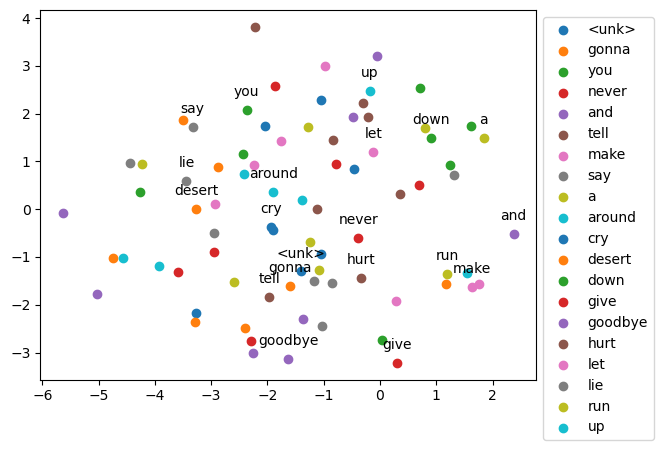

In [36]:
X = model_2.embeddings.weight.cpu().detach().numpy()
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

labels = []

for j in range(len(X_2d)):
    if j < 20:
        plt.scatter(X_2d[j, 0], X_2d[j, 1], label=index_to_token[j])
        labels.append(index_to_token[j])
        # Add words as annotations
        plt.annotate(index_to_token[j],
                     (X_2d[j, 0], X_2d[j, 1]),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center')
    else:
        plt.scatter(X_2d[j, 0], X_2d[j, 1])

plt.legend(labels, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [37]:
import numpy as np
print(np.__version__)

1.26.4


In [38]:
CONTEXT_SIZE=4
model_4 = NGramLanguageModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE).to(device)
optimizer = optim.SGD(model_4.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)
my_loss=train(dataloader,model_4,song)

save_path = '4gram.pth'
torch.save(model_4.state_dict(), save_path)

my_loss_list.append(my_loss)

  6%|▌         | 6/100 [00:00<00:03, 26.92it/s]

Generated Song:


We are no strangers to love <unk> <unk> aching other <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> run never <unk> <unk> never <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> never <unk> <unk> <unk> <unk> never <unk> <unk> you if <unk> <unk> <unk> <unk> <unk> you <unk> <unk> <unk> <unk> <unk> you <unk> <unk> <unk> <unk> <unk> you <unk> <unk> <unk> <unk> <unk> you <unk> never <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> you <unk> <unk> <unk> <unk> you never never <unk> <unk> <unk> <unk> <unk> <unk> <unk> never understand around <unk> dont feeling <unk> if <unk> <unk> <unk> <unk>


 14%|█▍        | 14/100 [00:00<00:02, 30.30it/s]

Generated Song:


Never gonna tell a lie and hurt you never <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> never <unk> never tell you never <unk> you <unk> <unk> never <unk> never <unk> <unk> <unk> <unk> never never <unk> <unk> <unk> you you down never <unk> <unk> <unk> tell you never never <unk> <unk> give you down never <unk> <unk> tell you down never <unk> <unk> tell you you never you never <unk> <unk> make you never never <unk> <unk> say you never <unk> <unk> tell you down never you you never <unk> <unk> make you never you never <unk> <unk> <unk> you never <unk> <unk> <unk> <unk>


 25%|██▌       | 25/100 [00:00<00:02, 30.55it/s]

...

 85%|████████▌ | 85/100 [00:02<00:00, 32.63it/s]

Generated Song:


Never gonna give you up never are no strangers to love you know the rules and were <unk> never a full commitments what im thinking down know <unk> im this from any other guy i to been <unk> tell you how im feeling <unk> <unk> tell you understand never <unk> <unk> give you up never <unk> <unk> let you down never <unk> <unk> give you and down you never <unk> <unk> make you understand never <unk> <unk> say goodbye never <unk> <unk> tell you lie never you you never known each other for so long tell say been aching but youre too shy to say


 97%|█████████▋| 97/100 [00:03<00:00, 31.78it/s]

Generated Song:


Never gonna give you up never are no strangers to love you know the rules and were <unk> never a full commitments what im thinking down know <unk> im this from any other guy i to been <unk> tell you how im feeling <unk> <unk> tell you understand never <unk> <unk> give you up never <unk> <unk> let you down never <unk> <unk> give you and down you never <unk> <unk> make you understand never <unk> <unk> say goodbye never <unk> <unk> tell you lie never you you never known each other for so long tell say been aching but youre too shy to say


100%|██████████| 100/100 [00:03<00:00, 31.54it/s]


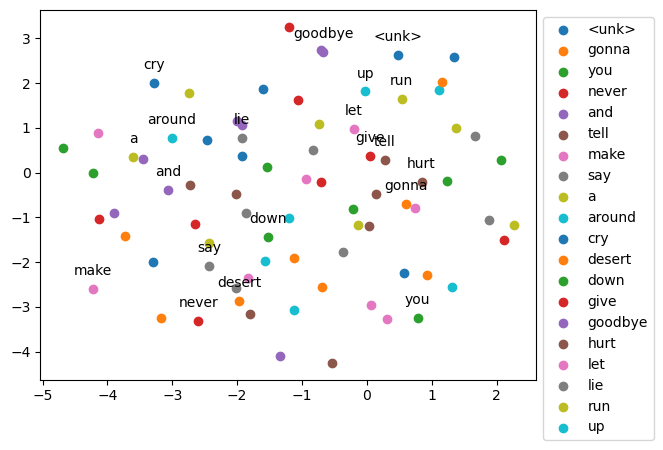

In [39]:
X = model_4.embeddings.weight.cpu().detach().numpy()
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

labels = []

for j in range(len(X_2d)):
    if j < 20:
        plt.scatter(X_2d[j, 0], X_2d[j, 1], label=index_to_token[j])
        labels.append(index_to_token[j])
        # Add words as annotations
        plt.annotate(index_to_token[j],
                     (X_2d[j, 0], X_2d[j, 1]),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center')
    else:
        plt.scatter(X_2d[j, 0], X_2d[j, 1])

plt.legend(labels, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [40]:
CONTEXT_SIZE=8
model_8 = NGramLanguageModeler(len(vocab), EMBEDDING_DIM, CONTEXT_SIZE).to(device)
optimizer = optim.SGD(model_8.parameters(), lr=0.01)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.1)
my_loss=train(dataloader,model_8,song)

save_path = '8gram.pth'
torch.save(model_8.state_dict(), save_path)

my_loss_list.append(my_loss)

  7%|▋         | 7/100 [00:00<00:02, 31.59it/s]

Generated Song:


Never gonna make you cry <unk> <unk> you you you <unk> you <unk> you <unk> you <unk> <unk> <unk> <unk> you you you you you you you you <unk> <unk> you <unk> <unk> you you you <unk> <unk> you you <unk> you <unk> <unk> <unk> <unk> you <unk> you <unk> <unk> <unk> you you you <unk> <unk> <unk> you you on <unk> <unk> <unk> you <unk> <unk> <unk> <unk> you <unk> you you you you <unk> <unk> <unk> you you <unk> <unk> <unk> you you so <unk> <unk> <unk> <unk> you you you you <unk> <unk> <unk> <unk> you <unk> <unk> you on you you


 15%|█▌        | 15/100 [00:00<00:02, 33.15it/s]

Generated Song:


And if you ask me how Im feeling <unk> <unk> make give to <unk> <unk> <unk> the <unk> <unk> <unk> <unk> <unk> <unk> <unk> tell you im <unk> <unk> you <unk> <unk> <unk> <unk> <unk> <unk> give you <unk> <unk> <unk> tell you <unk> <unk> <unk> <unk> <unk> give you <unk> give <unk> <unk> give you you never <unk> <unk> give you <unk> give <unk> <unk> give you <unk> <unk> <unk> <unk> <unk> <unk> make you cry never <unk> <unk> give you <unk> <unk> <unk> tell you lie im <unk> <unk> <unk> <unk> <unk> give you you <unk> <unk> <unk> <unk> <unk> <unk> tell you shy to <unk>


 27%|██▋       | 27/100 [00:00<00:02, 31.90it/s]

...

 87%|████████▋ | 87/100 [00:02<00:00, 35.56it/s]

Generated Song:


Gotta make you understand <unk> <unk> lie strangers to give <unk> up the rules <unk> <unk> <unk> <unk> never <unk> tell too im thinking for a other never been <unk> <unk> <unk> guy i cry long give you up lie im feeling <unk> <unk> give you cry never <unk> <unk> give you up never <unk> <unk> give a up never <unk> <unk> run around up never <unk> <unk> <unk> <unk> make you cry never <unk> <unk> give around <unk> never <unk> tell a lie never <unk> <unk> <unk> <unk> a other for so long never <unk> tell and <unk> tell too shy to say


 95%|█████████▌| 95/100 [00:02<00:00, 35.10it/s]

Generated Song:


I just wanna tell you how Im feeling <unk> <unk> lie strangers to give <unk> up the rules <unk> <unk> <unk> <unk> never <unk> tell too im thinking for a other never been <unk> <unk> <unk> guy i cry long give you up lie im feeling <unk> <unk> give you cry never <unk> <unk> give you up never <unk> <unk> give a up never <unk> <unk> run around up never <unk> <unk> <unk> <unk> make you cry never <unk> <unk> give around <unk> never <unk> tell a lie never <unk> <unk> <unk> <unk> a other for so long never <unk> tell and <unk> tell too shy to say


100%|██████████| 100/100 [00:02<00:00, 33.96it/s]


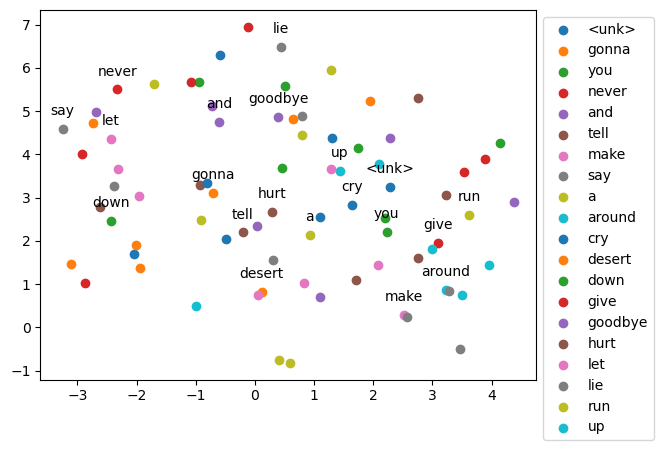

In [41]:
X = model_8.embeddings.weight.cpu().detach().numpy()
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

labels = []

for j in range(len(X_2d)):
    if j < 20:
        plt.scatter(X_2d[j, 0], X_2d[j, 1], label=index_to_token[j])
        labels.append(index_to_token[j])
        # Add words as annotations
        plt.annotate(index_to_token[j],
                     (X_2d[j, 0], X_2d[j, 1]),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center')
    else:
        plt.scatter(X_2d[j, 0], X_2d[j, 1])

plt.legend(labels, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

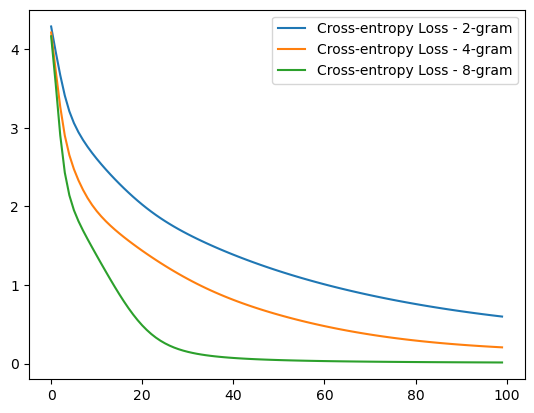

In [42]:
for (my_loss, model_name)in zip(my_loss_list,["2-gram","4-gram","8-gram"]):
    plt.plot(my_loss,label="Cross-entropy Loss - {}".format(model_name))
    plt.legend()

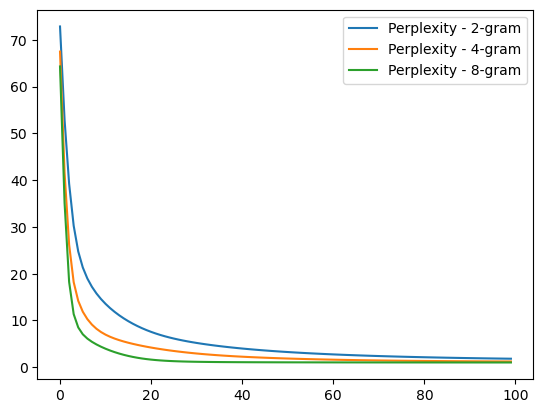

In [43]:
for (my_loss, model_name)in zip(my_loss_list,["2-gram","4-gram","8-gram"]):
    # Calculate perplexity using the loss
    perplexity = np.exp(my_loss)
    plt.plot(perplexity,label="Perplexity - {}".format(model_name))
    plt.legend()